# CS and SUN flux model: 

Figures:

- Figure 8
- Figure 9
- Figure 10

- FigureS25a
- FigureS25b
- FigureS28

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.dates import DateFormatter
import os
from scipy.stats import lognorm
import matplotlib.colors as colors
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from scipy.stats import mannwhitneyu
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.rcParams["font.family"] = 'monospace'

In [100]:
# Define paths relative to notebook location
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

idea is to create two CS vs. Sun grids and count the number of data points: 

In [ ]:
current_dir = r'C:\Users\Dell\Documents\AR_2025'
nano_ranking_dir = r'C:\Users\Dell\Documents\AR_2025\ZEP_processed_files\nano_ranking'
classification_dir = r'C:\Users\Dell\Documents\NAIS_work\Classification'

df_CS_hourly = pd.read_csv(current_dir+'\\Analysis\\CS\\CS_hourly.dat', index_col=0, parse_dates=True)
df_6hr = pd.read_csv(current_dir+'\\Analysis\\traj_solar\\solar_6hr.dat', index_col=0,
                    parse_dates=True)
df_g_timeseries = pd.read_csv(nano_ranking_dir+'\\g.dat', index_col=0,
                              parse_dates=True)
ZEP_class = pd.read_csv(classification_dir+'\\ZEP_class_DalMaso.txt', index_col=0, 
                            parse_dates=True)

In [3]:
df_sun_cs_hr = df_6hr.merge(df_CS_hourly, left_index=True, right_index=True) #hourly data
df_sun_cs_hr_ = df_sun_cs_hr.copy()

df_sun_cs_hr['month'] = df_sun_cs_hr.index.month
use_line = True
df_sun_cs_hr = df_sun_cs_hr.copy()

In [4]:
df_sun_cs_hr.head(2)

,SUN_FLUX,Traj_num,time_step,ensembles,ML,all_sunflux,all_Traj_num,all_time_step,all_ensembles,CS,month
arrival_time,,,,,,,,,,,
2022-04-17 12:00:00,736.940741,189,7.0,27.0,0.878307,844.885185,189,7.0,27.0,0.000329,4
2022-04-17 13:00:00,801.362963,189,7.0,27.0,0.846561,964.570370,189,7.0,27.0,0.000311,4


In [ ]:
df_events = ZEP_class[['Class Ia', 'Class Ib', 'Class II']].sum(axis=1).to_frame(name='event')
df_sunflux_cs = df_sun_cs_hr.dropna(how='any')
df_sunflux_cs['date'] = df_sunflux_cs.index.date
df_sunflux_cs = df_sunflux_cs.set_index('date')

df_merged = df_sunflux_cs.merge(df_g_timeseries, left_index=True, right_index=True)

df_g2g3 = df_merged[df_merged['g'].isin(['g3', 'g2'])]
df = df_sunflux_cs.copy()

16891


In [ ]:
def get_m(x1=0, y1=0, y2=8000, x2=0.4*10**(-3)):
    m = ((y2-y1)/(x2-x1))
    return m

def func(x, x1=0, y1=0, y2=8000, x2=0.4*10**(-3)): 
    m = get_m(x1=0, y1=0, y2=8000, x2=0.4*10**(-3))
    if x > 0:
        y = ((y2-y1)/(x2-x1))*(x - x1)+y1
    if x == 0:
        y=0
    return y

def polormesh_plot(pivot_df, vmin=0, vmax=.2, NAIS_var='neg_particles', CS_var='CS', backtraj_var='SUN_FLUX_sum',
                  ymax=40000, y2=8000, x2=0.6*10**(-3), plot_line=True, use_log_scale=False, vmin_log=None, 
                  vmax_log=None, letter_caption='', colorbar_label='Normalised Count [-]', cb_labelpad=12, cb_fontsize=12, 
                  plot_title='', cmap='jet', intercept=1000, fontsize=10):
    X, Y = np.meshgrid(pivot_df.columns, pivot_df.index)

    fig, ax = plt.subplots(figsize=(6, 3))
    
    if use_log_scale == False:
        plt.pcolormesh(X, Y, pivot_df.values, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax) #
    if use_log_scale == True:
        plt.pcolormesh(X, Y, pivot_df.values, shading='auto', cmap=cmap, 
                   norm=colors.LogNorm(vmin=vmin_log, vmax=vmax_log))
    cbar = plt.colorbar(label='Average '+str(NAIS_var))    
    ax.set_ylim(0, ymax) #40000
    ax.set_title(plot_title, loc='left', fontsize=fontsize)
    ax.set_ylabel('Accumulated Solar Flux [h Wm$^{-2}$]')
    ax.set_xlabel('Condensation sink [s$^{-1}$]') 
    ax.text(0.01*10**(-3), 4200, letter_caption, size=fontsize, color='k')
    x = np.arange(0, 10**(-3), step=10**(-5))
    y = [func(i, x1=0, y1=1000, y2=y2, x2=x2) for i in x]
    m = int(get_m(x1=0, y1=0, y2=y2, x2=x2))
    y = [i*m + intercept for i in x]
    if plot_line == True:
        ax.plot(x[::10], y[::10], 'o-', c='r', lw=5, ms=0, alpha=.6, label='y = '+str(m)+'x +'+str(intercept))
    cbar.set_label(colorbar_label, rotation=270, labelpad=cb_labelpad, fontsize=cb_fontsize)
    cbar.ax.tick_params(labelsize=15)
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.show()
    return fig

def get_pivot_table(df, NAIS_var='neg_particles', CS_var='CS', backtraj_var='SUN_FLUX_sum',
                    ymax=4*10**4, ystep=1000/5, cs_max=1*10**(-3), cs_step=2*10**(-5)):    
    df = df.dropna(subset=[NAIS_var, CS_var, backtraj_var], how='any')
    sunbins=np.arange(0, ymax, ystep) 
    csbins = np.arange(0, cs_max, cs_step) #csbins=np.arange(0, 1*10**(-3), 2*10**(-5))    
    df[str(backtraj_var)+'_bin'] = pd.cut(df[backtraj_var], bins=sunbins) # Define the number of bins for SUN_FLUX_sum and CS
    df[str(CS_var)+'_bin'] = pd.cut(df[CS_var], bins=csbins)
    agg_df = df.groupby([str(backtraj_var)+'_bin', str(CS_var)+'_bin'],
                        observed=False).agg({NAIS_var: 'count'}).reset_index() # Aggregate the data
    agg_df = agg_df.copy()
    agg_df[str(backtraj_var)+'_bin_mid'] = agg_df[str(backtraj_var)+'_bin'].apply(lambda x: x.mid) # Extract bin labels
    agg_df[str(CS_var)+'_bin_mid'] = agg_df[str(CS_var)+'_bin'].apply(lambda x: x.mid)
    # Pivot the data to create a grid
    pivot_df = agg_df.pivot(index=str(backtraj_var)+'_bin_mid', columns=str(CS_var)+'_bin_mid', values=NAIS_var)
    return pivot_df

13333333


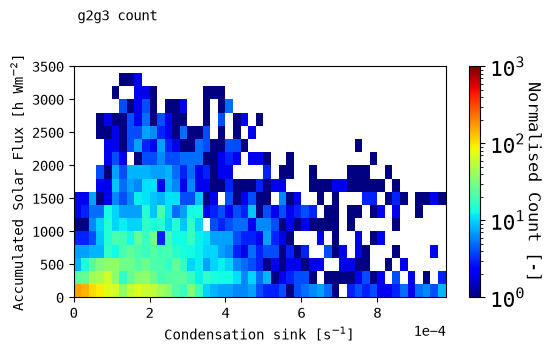

13333333


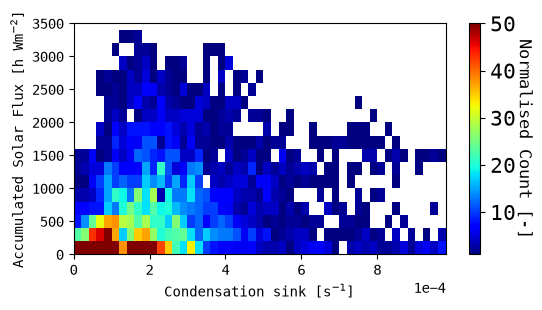

13333333


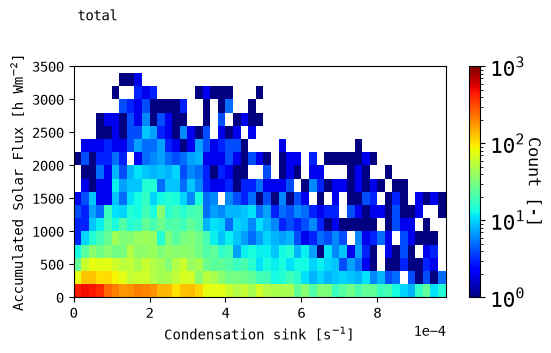

In [ ]:
total_count = get_pivot_table(df, NAIS_var='CS', CS_var='CS', backtraj_var='SUN_FLUX', 
                   ymax=3500)
g2g3_count = get_pivot_table(df_g2g3, NAIS_var='CS', CS_var='CS', backtraj_var='SUN_FLUX',
                   ymax=3500)
g2g3_norm = g2g3_count/total_count

fig = polormesh_plot(g2g3_count, vmax=50, ymax=3500,vmin_log=10**0, vmax_log=10**3, plot_line=False, use_log_scale=True, 
               letter_caption='g2g3 count')

g2g3_count = g2g3_count.replace(0, np.nan)
fig = polormesh_plot(g2g3_count, ymax=3500, vmin=1, vmax=50, plot_line=False, use_log_scale=False)

fig = polormesh_plot(total_count, vmax=50, ymax=3500, vmin_log=10**0, vmax_log=10**3, plot_line=False, use_log_scale=True, 
               letter_caption='total', colorbar_label='Count [-]')

## total sun: 

13333333


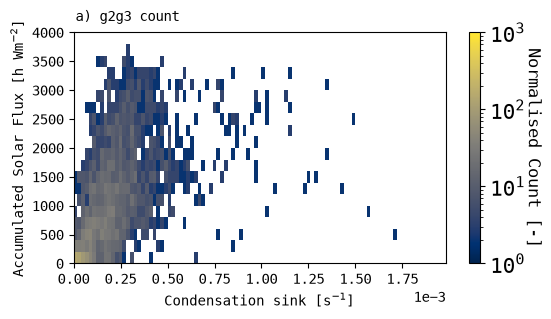

13333333


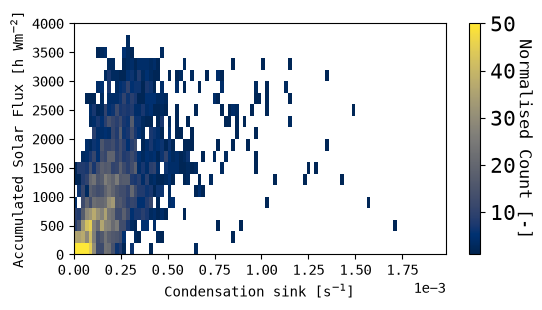

13333333


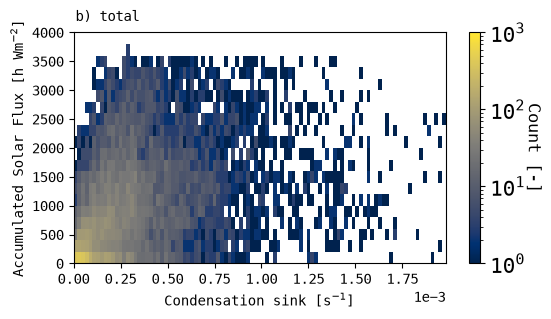

5000000


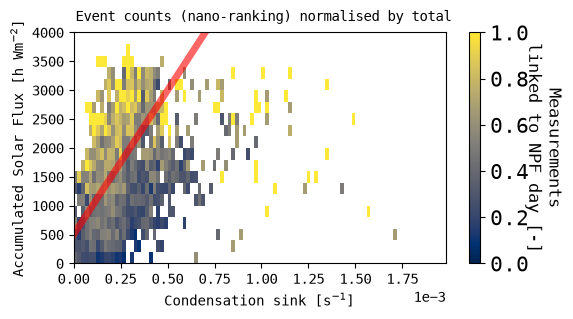

In [ ]:
ymax=4000
cs_max=2*10**(-3)
count_threshold=1

total_count = get_pivot_table(df, NAIS_var='CS', CS_var='CS', backtraj_var='all_sunflux', 
                   ymax=ymax, cs_max=cs_max)
g2g3_count = get_pivot_table(df_g2g3, NAIS_var='CS', CS_var='CS', backtraj_var='all_sunflux', 
                   ymax=ymax, cs_max=cs_max)
g2g3_count = g2g3_count[g2g3_count>count_threshold]
g2g3_norm = g2g3_count/total_count

fig = polormesh_plot(g2g3_count, vmax=50, ymax=ymax, vmin_log=10**0, vmax_log=10**3, 
               plot_line=False, use_log_scale=True, 
               letter_caption='a) g2g3 count', cmap='cividis')
output_figure = plots_outpath / 'FigureS25a.jpeg'
save_plot(fig, output_figure)

g2g3_count = g2g3_count.replace(0, np.nan)


fig = polormesh_plot(g2g3_count, ymax=ymax, vmin=1, vmax=50, plot_line=False, 
               use_log_scale=False, cmap='cividis')
output_figure = plots_outpath / 'FigureS25b.jpeg'
save_plot(fig, output_figure)


In [ ]:
fig = polormesh_plot(g2g3_norm, vmax=1, ymax=4000, x2=0.7*10**(-3), y2=3500, letter_caption='Event counts (nano-ranking) normalised by total',
               colorbar_label='Measurements\nlinked to NPF day [-]',cmap='cividis',
               cb_labelpad=25, cb_fontsize=12, intercept=500, fontsize=10)

output_figure = plots_outpath / 'Figure_8.jpeg'
save_plot(fig, output_figure)

## Add ROI equation: 

In [9]:
intercept=500
m=5*10**6
sun_var_to_use = 'all_sunflux' #'SUN_FLUX', 'all_sunflux'

df_sunflux_cs = df_sun_cs_hr[[sun_var_to_use,'CS']].dropna(how='any')
df_sunflux_cs['date'] = df_sunflux_cs.index.date
df_sunflux_cs = df_sunflux_cs.set_index('date')

print(df_sunflux_cs.head(2))

df_sunflux_cs['mxCS'] = df_sunflux_cs['CS'].apply(lambda x: x*m+intercept) 
df_sunflux_cs['ROI'] = df_sunflux_cs.apply(lambda row: row[sun_var_to_use]>= row['mxCS'], axis=1)

df_sunflux_cs_nano = df_sunflux_cs.merge(df_g_timeseries, left_index=True, right_index=True)
 
##NPF events
df_g2g3 = df_sunflux_cs_nano[df_sunflux_cs_nano['g'].isin(['g3', 'g2'])].copy()

            all_sunflux        CS
date                             
2022-04-17   844.885185  0.000329
2022-04-17   964.570370  0.000311


## Number of events in ROI: 

In [10]:
df_g_timeseries_ = df_g_timeseries.copy()
df_g_timeseries_['date'] = df_g_timeseries_.index.date

df_sunflux_cs_ = df_sunflux_cs.copy()
df_sunflux_cs_ = df_sunflux_cs_.reset_index()

df_sunflux_cs_merged = df_sunflux_cs_.merge(df_g_timeseries_, left_on='date', right_on='date')

df_g_timeseries_['g_event'] = df_g_timeseries_['g'].replace({'g1':0, 'g2':1, 'g3':1})

df_g_timeseries_events = df_g_timeseries_[df_g_timeseries_['g_event']==1]
df_g_timeseries_events['g_event_index'] = np.arange(1, len(df_g_timeseries_events)+1, 1)

df_sunflux_cs_merged = df_sunflux_cs_.merge(df_g_timeseries_events, left_on='date', right_on='date')
df_sunflux_cs_merged_all = df_sunflux_cs_.merge(df_g_timeseries_, left_on='date', right_on='date')

total_number_of_unique_events = len(df_sunflux_cs_merged.groupby('date')['g_event_index'].value_counts())
total_number_of_unique_events_notROI = len(df_sunflux_cs_merged[df_sunflux_cs_merged['ROI']==False]['g_event_index'].value_counts())
total_number_of_unique_events_inROI = df_sunflux_cs_merged[df_sunflux_cs_merged['ROI']==True]['g_event_index'].value_counts()

percentage_nonROI = len(df_sunflux_cs_merged[df_sunflux_cs_merged['ROI']==False])/len(df_sunflux_cs_merged)
percentage_ROI = len(df_sunflux_cs_merged[df_sunflux_cs_merged['ROI']==True])/len(df_sunflux_cs_merged)

In [11]:
data_linked_to_event = len(df_sunflux_cs_merged[df_sunflux_cs_merged['ROI']==True][df_sunflux_cs_merged['g_event']==1])
ROI_data = len(df_sunflux_cs_merged_all[df_sunflux_cs_merged_all['ROI']==True])

fraction_event = data_linked_to_event/ROI_data
print(fraction_event)

#Non-ROI
data_linked_to_event_nonROI = len(df_sunflux_cs_merged[df_sunflux_cs_merged['ROI']==False][df_sunflux_cs_merged['g_event']==1])
nonROI_data = len(df_sunflux_cs_merged_all[df_sunflux_cs_merged_all['ROI']==False])

fraction_event = data_linked_to_event_nonROI/nonROI_data
print(fraction_event)

0.6247877758913413
0.23809838667019306


C:\Users\Dell\AppData\Local\Temp\ipykernel_17108\392927873.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_linked_to_event = len(df_sunflux_cs_merged[df_sunflux_cs_merged['ROI']==True][df_sunflux_cs_merged['g_event']==1])
C:\Users\Dell\AppData\Local\Temp\ipykernel_17108\392927873.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_linked_to_event_nonROI = len(df_sunflux_cs_merged[df_sunflux_cs_merged['ROI']==False][df_sunflux_cs_merged['g_event']==1])


In [12]:
number_of_unique_events_notinROI = len(df_sunflux_cs_merged[df_sunflux_cs_merged['ROI']==False][df_sunflux_cs_merged['g_event']==1]['g_event_index'].unique())
print(number_of_unique_events_notinROI)
number_of_unique_events_in_ROI = len(df_sunflux_cs_merged[df_sunflux_cs_merged['ROI']==True][df_sunflux_cs_merged['g_event']==1]['g_event_index'].unique())
print(number_of_unique_events_in_ROI)
number_of_unique_events = len(df_sunflux_cs_merged['g_event_index'].unique())
print(number_of_unique_events)

print(number_of_unique_events_notinROI/number_of_unique_events)

print(number_of_unique_events_in_ROI/number_of_unique_events)

203
115
208
0.9759615384615384
0.5528846153846154


C:\Users\Dell\AppData\Local\Temp\ipykernel_17108\3145296549.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  number_of_unique_events_notinROI = len(df_sunflux_cs_merged[df_sunflux_cs_merged['ROI']==False][df_sunflux_cs_merged['g_event']==1]['g_event_index'].unique())
C:\Users\Dell\AppData\Local\Temp\ipykernel_17108\3145296549.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  number_of_unique_events_in_ROI = len(df_sunflux_cs_merged[df_sunflux_cs_merged['ROI']==True][df_sunflux_cs_merged['g_event']==1]['g_event_index'].unique())


13333333


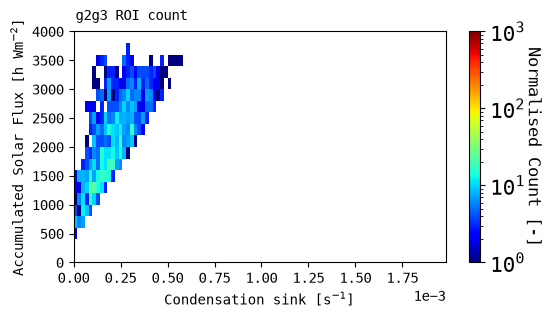

13333333


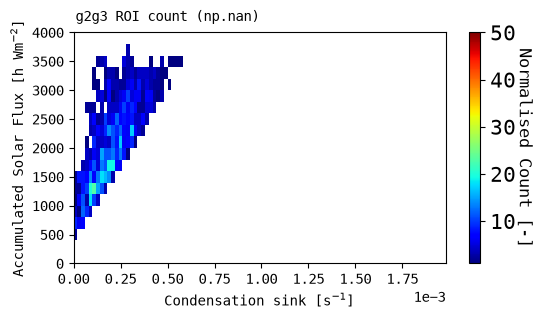

13333333


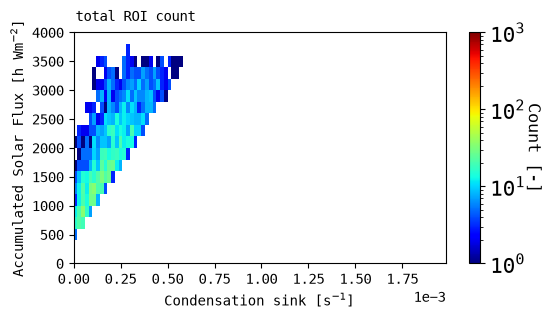

5000000


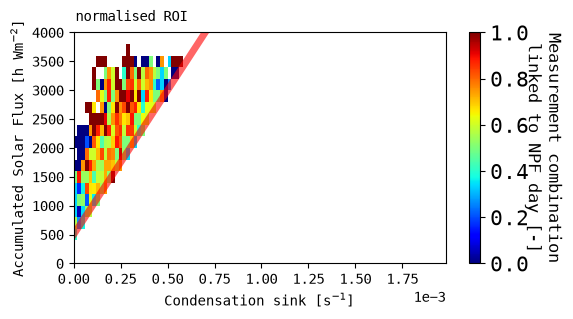

In [13]:
ymax=4000
cs_max=2*10**(-3)
count_threshold=2
count_threshold=None

# df_sunflux_cs_nano = df_sunflux_cs_nano[df_sunflux_cs_nano['ROI'] == True].copy()

df_total = df_sunflux_cs_nano.copy()

df_g2g3 = df_sunflux_cs_nano[df_sunflux_cs_nano['g'].isin(['g3', 'g2'])].copy()
df_g2g3events = df_g2g3.copy()

df_g2g3events_ROI = df_g2g3events[df_g2g3events['ROI'] == True].copy()
df_total_ROI = df_total[df_total['ROI'] == True].copy()

total_ROI_count = get_pivot_table(df_total_ROI, NAIS_var='CS', CS_var='CS', 
                    backtraj_var=sun_var_to_use, 
                    ymax=ymax, cs_max=cs_max)
g2g3events_ROI_count = get_pivot_table(df_g2g3events_ROI, NAIS_var='CS', CS_var='CS', 
                   backtraj_var=sun_var_to_use, 
                   ymax=ymax, cs_max=cs_max)

if count_threshold is not None:
    g2g3events_ROI_count = g2g3events_ROI_count[g2g3events_ROI_count>count_threshold]

g2g3events_ROI_norm = g2g3events_ROI_count/total_ROI_count

polormesh_plot(g2g3events_ROI_count, vmax=50, ymax=ymax, vmin_log=10**0, vmax_log=10**3, 
               plot_line=False, use_log_scale=True, 
               letter_caption='g2g3 ROI count')

g2g3events_ROI_count_npnan = g2g3events_ROI_count.replace(0, np.nan)

polormesh_plot(g2g3events_ROI_count_npnan, ymax=ymax, vmin=1, vmax=50, plot_line=False, 
               use_log_scale=False, letter_caption='g2g3 ROI count (np.nan)')

polormesh_plot(total_ROI_count, vmax=50, ymax=ymax, vmin_log=10**0, vmax_log=10**3, 
               plot_line=False, use_log_scale=True, 
               letter_caption='total ROI count', colorbar_label='Count [-]')

polormesh_plot(g2g3events_ROI_norm, vmax=1, ymax=4000, x2=0.7*10**(-3), y2=3500, 
               letter_caption='normalised ROI',
               colorbar_label='Measurement combination\nlinked to NPF day [-]',
               cb_labelpad=25, cb_fontsize=12, intercept=500)

In [14]:
g2g3events_ROI_norm.head(2)

CS_bin_mid,0.00001,0.00003,0.00005,0.00007,0.00009,0.00011,0.00013,0.00015,0.00017,0.00019,...,0.00179,0.00181,0.00183,0.00185,0.00187,0.00189,0.00191,0.00193,0.00195,0.00197
all_sunflux_bin_mid,,,,,,,,,,,,,,,,,,,,,
100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
g2g3events_ROI_table_SUN_CS = g2g3events_ROI_norm.stack().reset_index().dropna(how='any')[[str(sun_var_to_use )+'_bin_mid','CS_bin_mid']]
g2g3events_ROI_table_SUN_CS['ROI'] = 1

In [16]:
g2g3events_ROI_table_SUN_CS.head(2)

,all_sunflux_bin_mid,CS_bin_mid,ROI
198,500.0,0.00001,1
297,700.0,0.00001,1


In [17]:
def add_bins_to_df(df, NAIS_var='CS', CS_var='CS', backtraj_var='SUN_FLUX',
                    ymax=4*10**4, ystep=1000/5, cs_max=1*10**(-3), cs_step=2*10**(-5)):    
    df = df.dropna(subset=[NAIS_var, CS_var, backtraj_var], how='any')
    sunbins=np.arange(0, ymax, ystep) 
    csbins = np.arange(0, cs_max, cs_step)  
    df[str(backtraj_var)+'_bin'] = pd.cut(df[backtraj_var], bins=sunbins) # Define the number of bins for SUN_FLUX_sum and CS
    df[str(CS_var)+'_bin'] = pd.cut(df[CS_var], bins=csbins)
    df[str(backtraj_var)+'_bin_mid'] = df[str(backtraj_var)+'_bin'].map(lambda x: x.mid if pd.notna(x) else np.nan)
        #.apply(lambda x: x.mid) # Extract bin labels
    df[str(CS_var)+'_bin_mid'] = df[str(CS_var)+'_bin'].map(lambda x: x.mid if pd.notna(x) else np.nan)
    #.apply(lambda x: x.mid)
    return df

def get_agg_df(df, NAIS_var='CS', CS_var='CS', backtraj_var='SUN_FLUX',
                    ymax=4*10**4, ystep=1000/5, cs_max=1*10**(-3), cs_step=2*10**(-5)):    
    df = add_bins_to_df(df, NAIS_var='CS', CS_var='CS', backtraj_var='SUN_FLUX',
                    ymax=ymax, ystep=ystep, cs_max=cs_max, cs_step=cs_step)
    agg_df = df.groupby([str(backtraj_var)+'_bin', str(CS_var)+'_bin']).agg({NAIS_var: 'count'}).reset_index() # Aggregate the data
    agg_df = agg_df.copy()
    agg_df[str(backtraj_var)+'_bin_mid'] = agg_df[str(backtraj_var)+'_bin'].apply(lambda x: x.mid) # Extract bin labels
    agg_df[str(CS_var)+'_bin_mid'] = agg_df[str(CS_var)+'_bin'].apply(lambda x: x.mid)
    agg_df[['SUN_FLUX_bin_mid', 'CS_bin_mid']] = agg_df[['SUN_FLUX_bin_mid', 'CS_bin_mid']].astype(np.float64)
    return agg_df

In [18]:
df_sun_cs_hr.head(2)

,SUN_FLUX,Traj_num,time_step,ensembles,ML,all_sunflux,all_Traj_num,all_time_step,all_ensembles,CS,month
arrival_time,,,,,,,,,,,
2022-04-17 12:00:00,736.940741,189,7.0,27.0,0.878307,844.885185,189,7.0,27.0,0.000329,4
2022-04-17 13:00:00,801.362963,189,7.0,27.0,0.846561,964.570370,189,7.0,27.0,0.000311,4


In [19]:
df_sun_cs_hr_bins = add_bins_to_df(df_sun_cs_hr[[sun_var_to_use,'CS']].dropna(how='any'),
                                   backtraj_var=sun_var_to_use)
df_sun_cs_hr_bins['Datetime'] = df_sun_cs_hr_bins.index

df_sun_cs_hr_bins = df_sun_cs_hr_bins.merge(g2g3events_ROI_table_SUN_CS, 
                                            on=[str(sun_var_to_use)+'_bin_mid', 'CS_bin_mid'], 
                                            how='left')

df_sun_cs_hr_bins['ROI'] = df_sun_cs_hr_bins['ROI'].replace(np.nan, 0)
df_sun_cs_hr_bins = df_sun_cs_hr_bins.set_index('Datetime')

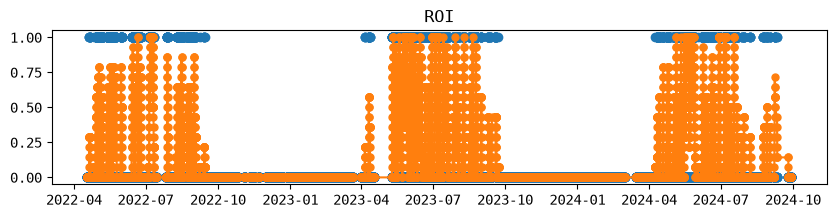

In [20]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(df_sun_cs_hr_bins.index, df_sun_cs_hr_bins['ROI'], 'o')
ax.plot(df_sun_cs_hr_bins.index, df_sun_cs_hr_bins['ROI'].rolling(window=14, center=True, min_periods=3).mean(),'o-', ms=5)
ax.set_title('ROI')
plt.show()

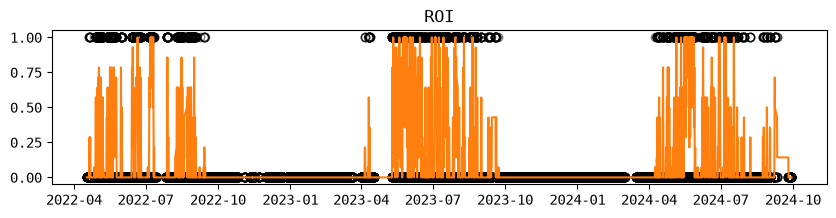

In [21]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(df_sun_cs_hr_bins.index, df_sun_cs_hr_bins['ROI'], 'o', label='binary value (ROI)', alpha=.5, mec='k', mfc='None')
ax.plot(df_sun_cs_hr_bins.index, 
        df_sun_cs_hr_bins['ROI'].rolling(window=14, center=True, min_periods=3).mean(),'-', ms=3, 
        label='rolling mean applied to binary value')
ax.set_title('ROI')
plt.show()

In [22]:
df_rolling = df_sun_cs_hr_bins['ROI'].rolling(window=14, center=True, min_periods=3).mean().to_frame(name='rolling')

In [23]:
df_sun_cs_hr_bins.head(2)

,all_sunflux,CS,all_sunflux_bin,CS_bin,all_sunflux_bin_mid,CS_bin_mid,ROI
Datetime,,,,,,,
2022-04-17 12:00:00,844.885185,0.000329,"(800.0, 1000.0]","(0.00032, 0.00034]",900.0,0.00033,0.0
2022-04-17 13:00:00,964.570370,0.000311,"(800.0, 1000.0]","(0.0003, 0.00032]",900.0,0.00031,0.0


In [24]:
df_sun_cs_hr_bins_D = df_sun_cs_hr_bins[[sun_var_to_use,'CS', 'ROI']].resample('D').mean()

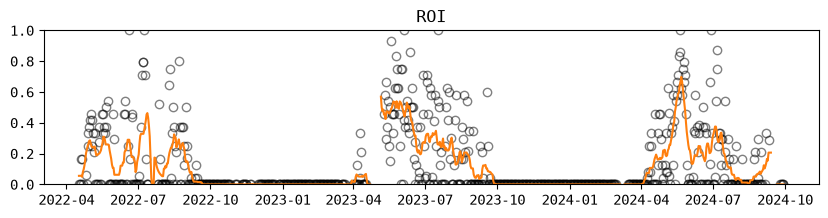

In [25]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(df_sun_cs_hr_bins_D.index, df_sun_cs_hr_bins_D['ROI'], 'o', label='binary value (ROI)', alpha=.5, mec='k', mfc='None')
ax.plot(df_sun_cs_hr_bins_D.index, 
        df_sun_cs_hr_bins_D['ROI'].rolling(window=14, center=True, min_periods=3).mean(),'-', ms=3, 
        label='rolling mean applied to binary value')
ax.set_title('ROI')
ax.set_ylim(0, 1)
plt.show()

In [27]:
df_sun_cs_hr_bins_D_all = df_sun_cs_hr_bins_D.copy().sort_index()

In [29]:
ZEP_class['event'] = ZEP_class[['Class Ia', 'Class Ib', 'Class II']].sum(axis=1)
ZEP_class['total'] = ZEP_class[['Class Ia', 'Class Ib', 'Class II', 'Undefined', 'Non-event']].sum(axis=1)
ZEP_class['event_norm'] = ZEP_class['event']/ZEP_class['total']

In [30]:
ZEP_class.head(2)

,Class Ia,Class Ib,Class II,Undefined,Non-event,too little data,maso comments,windblown seen in DMPS,month,year,month_year,event,total,event_norm
datetime,,,,,,,,,,,,,,
2022-04-17,NaN,NaN,NaN,NaN,NaN,1.0,could be class I,NaN,4,2022,16,0.0,0.0,NaN
2022-04-18,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,4,2022,16,1.0,1.0,1.0


In [31]:
df_g = df_g_timeseries.replace('g1', 0).replace('g2', 1).replace('g3', 1)
ZEP_freq = ZEP_class[['event_norm']].copy()

df_sunflux_cs_hr = df_sun_cs_hr_.copy()
df_sunflux_cs_hr.index = pd.to_datetime(df_sunflux_cs_hr.index)
df_sunflux_cs_D = df_sunflux_cs_hr[['SUN_FLUX','all_sunflux','CS']].resample('D').mean()

df_g_sunflux_cs_D = df_sunflux_cs_D.merge(df_g, left_index=True, right_index=True)
df_g_sunflux_cs_D_freq = df_g_sunflux_cs_D.merge(ZEP_freq, left_index=True, right_index=True)

In [32]:
df_g_sunflux_cs_D_freq.head(2)

,SUN_FLUX,all_sunflux,CS,g,event_norm
arrival_time,,,,,
2022-04-17,557.151543,852.635802,0.000352,1,NaN
2022-04-18,650.519136,960.865586,0.000415,1,1.0


In [33]:
df_sun_cs_hr_bins_D_all.head(2)

,all_sunflux,CS,ROI
Datetime,,,
2022-04-17,852.635802,0.000352,0.0
2022-04-18,960.865586,0.000415,0.0


In [34]:
df_g_sunflux_cs_D_freq_model = df_g_sunflux_cs_D_freq.merge(df_sun_cs_hr_bins_D_all[['ROI']],
                                                            left_index=True, right_index=True)
df_g_sunflux_cs_D_freq_model = df_g_sunflux_cs_D_freq_model.sort_index()

In [35]:
df_g_sunflux_cs_D_freq_model.head(2)

,SUN_FLUX,all_sunflux,CS,g,event_norm,ROI
arrival_time,,,,,,
2022-04-17,557.151543,852.635802,0.000352,1,NaN,0.0
2022-04-18,650.519136,960.865586,0.000415,1,1.0,0.0


In [36]:
def prob_timeseries_plot(df, event_freq_dalmaso='event_norm', event_freq_g='g',
                          ylabel='N$_{\mathrm{2.8-5nm, max}}$ [-]', 
                          sunmax=2000, window_intense=30, min_periods_intense=7,
                          window_prob=30, min_periods_prob=7, ROI_max=.6): 
    fig, ax  = plt.subplots(1, 1, figsize=(10, 3), sharex=True)

    # 🔵 Blue: #0072B2
    # 🟠 Orange: #E69F00
    # 🟢 Bluish green: #009E73
        
    ax.plot(df.index, df[event_freq_dalmaso].rolling(window=window_intense, 
                                                       center=True, 
                                                       min_periods=min_periods_intense).mean(), c='#009E73', 
             label='Class Ia, Ib, II (Dal Maso)', alpha=.5,  ls='-.', lw=3, marker='x', markersize=1, 
             mfc='#009E73', mec='#009E73')
    ax.set_ylabel(ylabel, color='k', fontsize=15)    
    ax.plot(df.index, df[event_freq_g].rolling(window=window_intense, 
                                                center=True, 
                                                min_periods=min_periods_intense).mean(), c='#0072B2', alpha=.5,
             label='g2g3 (Aliaga)\n'+str(window_intense)+'-day roll. mean (min. window '+str(min_periods_intense)+'d)',
              ls=':', lw=2)   
    ax.set_ylabel(ylabel, color='k', fontsize=15,) 
    ax.legend(frameon=False, loc=1) 
    
    ax2 = ax.twinx()
    ax2.set_ylabel('$P_{NPF,D}$ (daily prob.\n ROI) [-]', color='#E69F00', fontsize=15, labelpad=3)
    ax2.plot(df.index, df['ROI'].rolling(window=window_prob, center=True, min_periods=2).mean(), ms=3, 
             c='#E69F00', lw=2, label='rolling mean to daily averages')      
    
    ax2.set_ylim(0, ROI_max)
    ax.set_ylim(0,1) 
    
    ax.legend(frameon=False, loc=1)  
    ax2.legend(frameon=False, loc=2)

    ax.set_title('Averaging window: '+str(window_prob)+' days', loc='left')
    for axes in [ax, ax2]:
        ax.set_xlim(pd.to_datetime('2022-04-01'), pd.to_datetime('2024-10-30'))
        ax2.set_xlim(pd.to_datetime('2022-04-01'), pd.to_datetime('2024-10-30'))
                    
    plt.show()
    return fig

<>:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_17108\3194183662.py:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ylabel='N$_{\mathrm{2.8-5nm, max}}$ [-]',


In [37]:
df_g_sunflux_cs_D_freq_model.head(2)

,SUN_FLUX,all_sunflux,CS,g,event_norm,ROI
arrival_time,,,,,,
2022-04-17,557.151543,852.635802,0.000352,1,NaN,0.0
2022-04-18,650.519136,960.865586,0.000415,1,1.0,0.0


In [38]:
def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

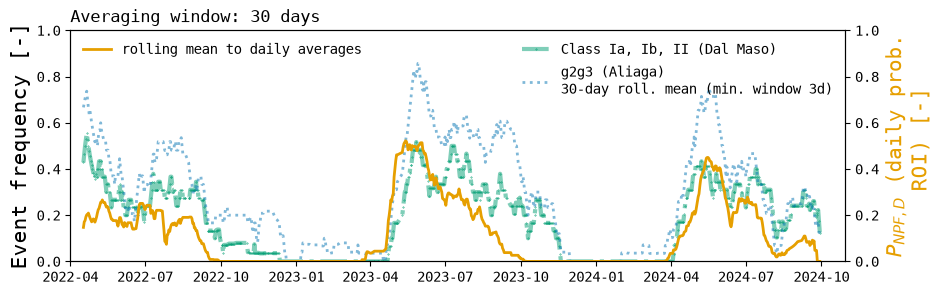

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_10.jpeg


In [39]:
fig = prob_timeseries_plot(df_g_sunflux_cs_D_freq_model, event_freq_g='g', 
                          ylabel='Event frequency [-]', 
                          sunmax=1, window_intense=30, min_periods_intense=3,
                          window_prob=30, min_periods_prob=3, ROI_max=1)

plots_outpath = r'c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots'
output_figure = plots_outpath + '\\' + 'Figure_10.jpeg'
save_plot(fig, output_figure)

In [40]:
df_g_sunflux_cs_D_freq_model = df_g_sunflux_cs_D_freq_model.loc[~df_g_sunflux_cs_D_freq_model.index.duplicated(keep='first'), :].copy()

In [41]:
df_g_sunflux_cs_D_freq.head(2)

,SUN_FLUX,all_sunflux,CS,g,event_norm
arrival_time,,,,,
2022-04-17,557.151543,852.635802,0.000352,1,NaN
2022-04-18,650.519136,960.865586,0.000415,1,1.0


In [42]:
window_ROI=14
min_periods_ROI=3
window_intense=14
min_periods_intense=3
window_prob=14
min_periods_prob=3
event_freq_g='g'
event_freq_dalmaso='event_norm'

df_ROI_rolling = df_g_sunflux_cs_D_freq_model['ROI'].rolling(window=window_ROI, center=True, min_periods=min_periods_ROI).mean().to_frame('ROI_roll')
df_Nano_rolling = df_g_sunflux_cs_D_freq_model[event_freq_g].rolling(window=window_intense,center=True, min_periods=min_periods_intense).mean().to_frame('Nano_roll')
df_DalMaso_rolling = df_g_sunflux_cs_D_freq_model[event_freq_dalmaso].rolling(window=window_intense, center=True, min_periods=min_periods_intense).mean().to_frame('Dalmaso_roll')

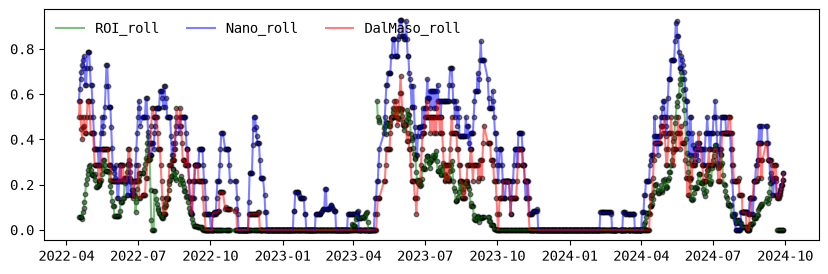

In [43]:
fig, ax  = plt.subplots(1, 1, figsize=(10, 3), sharex=True)
fig:plt.Figure
ax: plt.Axes
    
ax.scatter(df_ROI_rolling.index, df_ROI_rolling['ROI_roll'], s=10,alpha=.5, c='k',) 
ax.plot(df_ROI_rolling.index, df_ROI_rolling['ROI_roll'],
        c='green', label='ROI_roll', alpha=.5)

ax.scatter(df_Nano_rolling.index, df_Nano_rolling['Nano_roll'], s=10,alpha=.5, c='k',) 
ax.plot(df_Nano_rolling.index, df_Nano_rolling['Nano_roll'],
        c='blue', label='Nano_roll', alpha=.5)

ax.scatter(df_DalMaso_rolling.index, df_DalMaso_rolling['Dalmaso_roll'], s=10,alpha=.5, c='k',) 
ax.plot(df_DalMaso_rolling.index, df_DalMaso_rolling['Dalmaso_roll'],
        c='r', label='DalMaso_roll', alpha=.5)

plt.legend(ncol=3, frameon=False)
plt.show()

In [44]:
df_merged_model_obs_comparsion = df_ROI_rolling.merge(df_Nano_rolling, left_index=True, right_index=True)
df_merged_model_obs_comparsion = df_merged_model_obs_comparsion.merge(df_DalMaso_rolling, left_index=True, right_index=True)

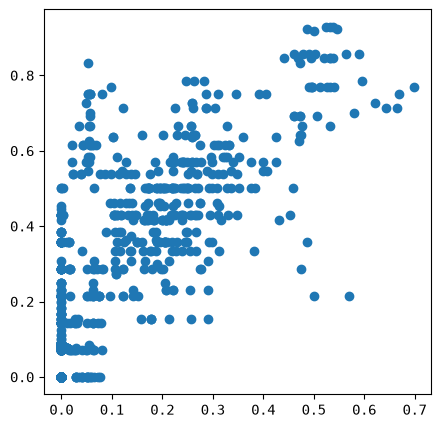

In [45]:
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(df_merged_model_obs_comparsion['ROI_roll'].values, df_merged_model_obs_comparsion['Nano_roll'].values, 'o')
plt.show()

<>:34: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:34: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_17108\3407264586.py:34: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
  label="OLS regression line\n"+"ROI freq. = {:.4f}$\,$Nano$\,$freq. $\,${:.4f}".format(slope,intercept)+"\nR² = {:.4f}".format(r2))


OLS Equation: ROI_roll = -0.0176 + 0.4570 * Nano_roll
R² = 0.5815


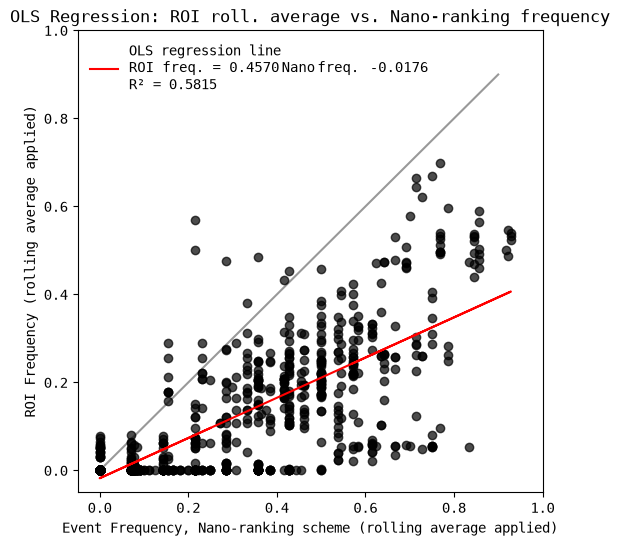

In [ ]:
independent = 'Dalmaso_roll'
independent = 'Nano_roll'

df = df_merged_model_obs_comparsion[[independent, 'ROI_roll']].copy()
df = df.dropna(how='any').copy() 

# Independent and dependent variables
X = df[independent]
y = df['ROI_roll']

# Add constant for OLS intercept
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()

# Get coefficients
intercept, slope = model.params

# R-squared
r2 = model.rsquared

print("OLS Equation: ROI_roll = {:.4f} + {:.4f} * Nano_roll".format(intercept, slope))
print("R² = {:.4f}".format(r2))

# Plot scatter + regression line
plt.figure(figsize=(6,6))
plt.scatter(df[independent], df['ROI_roll'], alpha=0.7, color='k')
plt.plot(df[independent], intercept + slope*df[independent], color="red", 
         label="OLS regression line\n"+"ROI freq. = {:.4f}$\,$Nano$\,$freq. $\,${:.4f}".format(slope,intercept)+"\nR² = {:.4f}".format(r2))
plt.plot(np.arange(0,1,.1),np.arange(0,1,.1), '-', c='k', alpha=.4)
plt.xlim(-0.05,1)
plt.ylim(-0.05,1)

plt.xlabel("Event Frequency, Nano-ranking scheme (rolling average applied)")
plt.ylabel("ROI Frequency (rolling average applied)")
plt.title("OLS Regression: ROI roll. average vs. Nano-ranking frequency")
plt.legend(frameon=False)
#plt.grid(True)
plt.show()


output_figure = plots_outpath / 'FigureS28.jpeg'
save_plot(fig, output_figure)

In [47]:
def OLS_plot(df_g_sunflux_cs_D_freq_N, dep_var='SUN_CS', indep_var='event_norm',
             window=30, min_periods=7, xlabel='Event Frequency (DalMaso, rolling mean applied)',
             ylabel='ROI occurance [-]'):
    df = df_g_sunflux_cs_D_freq_N[[indep_var, dep_var]].copy()
    df = df.dropna(how='any').copy() 
    df_roll_depvar = df[dep_var].rolling(window=window, center=True, min_periods=min_periods).mean().to_frame(dep_var)
    df_roll_indepvar = df[indep_var].rolling(window=window, center=True, min_periods=min_periods).mean().to_frame(indep_var)
    X = df_roll_indepvar[indep_var]
    y = df_roll_depvar[dep_var]
    # Add constant for OLS intercept
    X = sm.add_constant(X)
    # Fit OLS model
    model = sm.OLS(y, X).fit()
    # Get coefficients
    intercept, slope = model.params
    # R-squared
    r2 = model.rsquared
    fig, ax = plt.subplots(figsize=(5,5))
    dates = df.index
    sc = plt.scatter(df_roll_indepvar[indep_var].values, 
                df_roll_depvar[dep_var].values, alpha=0.7, c='k')
    ax.plot(np.arange(0, .9, .1), intercept + slope*np.arange(0, .9, .1), 
            color="red", 
            label="OLS:\ny = {:.2f} + {:.2f}x".format(intercept, slope)+"\nR² = {:.2f}".format(r2))
    ax.plot(np.arange(0, .9, .1), np.arange(0, .9, .1), color="k", alpha=.5)
    plt.xlabel(indep_var)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    #plt.title("OLS Regression: "+str(dep_var.replace('_','/'))+" vs. "+str(indep_var))
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.tick_params(axis='both', which='minor', labelsize=15)
    ax.legend(frameon=False)
    ax.set_xlim(-0.01, .82)
    ax.set_ylim(-0.01, .82)
    plt.show()
    return fig

In [48]:
df_merged_model_obs_comparsion.head(2)

,ROI_roll,Nano_roll,Dalmaso_roll
arrival_time,,,
2022-04-17,0.055556,0.571429,0.500000
2022-04-18,0.055556,0.625000,0.571429


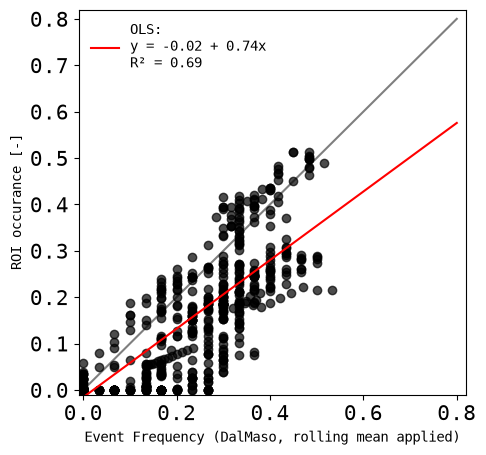

In [49]:
fig = OLS_plot(df_g_sunflux_cs_D_freq_model, dep_var='ROI', indep_var='event_norm',
             window=30, min_periods=7, xlabel='Event Frequency (DalMaso, rolling mean applied)',
             )

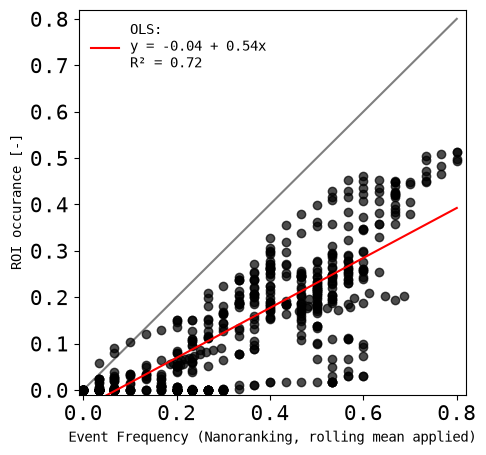

In [50]:
fig = OLS_plot(df_g_sunflux_cs_D_freq_model, dep_var='ROI', indep_var='g',
             window=30, min_periods=7, xlabel='Event Frequency (Nanoranking, rolling mean applied)',
             )

# Mann-Whiteny U test:

In [51]:
df_g = df_g_timeseries.replace('g1', 0).replace('g2', 1).replace('g3', 1)
ZEP_freq = ZEP_class[['event_norm']].copy()

df_sun_cs_hr = df_6hr.merge(df_CS_hourly, left_index=True, right_index=True) #hourly data
df_sunflux_cs = df_sun_cs_hr.dropna(how='any')

intercept = 500
m=5*10**6

df_sunflux_cs['mxCS'] = df_sunflux_cs['CS'].apply(lambda x: x*m+intercept) 
df_sunflux_cs['ROI'] = df_sunflux_cs.apply(lambda row: row[sun_var_to_use]>= row['mxCS'], axis=1)

df_sunflux_cs = df_sunflux_cs[['SUN_FLUX','all_sunflux','CS', 'ROI']].copy()
df_sunflux_cs = df_sunflux_cs.astype(np.float64)
df_sunflux_cs.index = pd.to_datetime(df_sunflux_cs.index)

########DAILY####################################

df_sunflux_cs_D = df_sunflux_cs.resample('D').mean()
df_g_sunflux_cs_D = df_sunflux_cs_D.merge(df_g, left_index=True, right_index=True)
df_g_sunflux_cs_D_freq = df_g_sunflux_cs_D.merge(ZEP_freq, left_index=True, right_index=True)

In [52]:
df_NPF_DalMaso_event = df_g_sunflux_cs_D_freq[df_g_sunflux_cs_D_freq['event_norm'] == 1].copy()
df_NPF_DalMaso_nonevent = df_g_sunflux_cs_D_freq[df_g_sunflux_cs_D_freq['event_norm'] == 0].copy()

df_NPF_g_event = df_g_sunflux_cs_D_freq[df_g_sunflux_cs_D_freq['g'] == 1].copy()
df_NPF_g_nonevent = df_g_sunflux_cs_D_freq[df_g_sunflux_cs_D_freq['g'] == 0].copy()

In [56]:
def compare_ROI_events_nonevents(df_g_sunflux_cs_D_freq, classification_type='g'):
    df_NPF_event = df_g_sunflux_cs_D_freq[df_g_sunflux_cs_D_freq[classification_type] == 1].copy()
    df_NPF_nonevent = df_g_sunflux_cs_D_freq[df_g_sunflux_cs_D_freq[classification_type] == 0].copy()

    fig, ax = plt.subplots(figsize=(5, 3))
    df_NPF_event = df_NPF_event[['ROI', classification_type]].dropna(how='any')
    df_NPF_nonevent = df_NPF_nonevent[['ROI', classification_type]].dropna(how='any')

    NPF_event = df_NPF_event['ROI'].values
    NPF_nonevent = df_NPF_nonevent['ROI'].values
    statistic, p_value = mannwhitneyu(NPF_event, NPF_nonevent, alternative='two-sided')
    print(f"Mann-Whitney U statistic: {statistic}")
    print(f"P-value: {p_value}")
    NPF_event_median = np.round(np.nanmean(NPF_event), 2)
    NPF_nonevent_median = np.round(np.nanmean(NPF_nonevent), 2)

    boxplot1 = df_NPF_event.boxplot(column=['ROI'], positions=[1], 
                                label=['med = '+str(NPF_event)], ax=ax) 
    boxplot2 = df_NPF_nonevent.boxplot(column=['ROI'], 
                                    label=['med = '+str(NPF_nonevent)], 
                                    positions=[2], ax=ax)
    ax.set_title('Event vs. non-event, '+str(NPF_event_median)+' vs. '+str(NPF_nonevent_median)+' [h Wm-2]')
    #ax.legend(frameon=False)
    ax.set_xticklabels(['Event', 'non-event'])
    ax.set_ylabel('ROI')
    ax.set_ylim(-0.1, 1.01)
    plt.show()
    return fig

Mann-Whitney U statistic: 71835.0
P-value: 6.287048489726528e-29


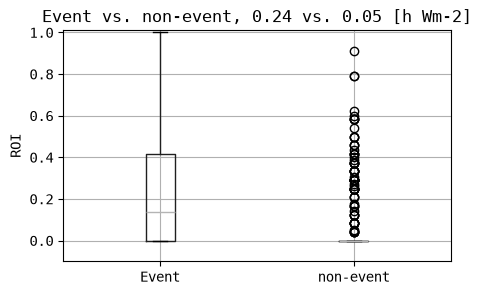

Mann-Whitney U statistic: 58392.0
P-value: 4.613728783420078e-22


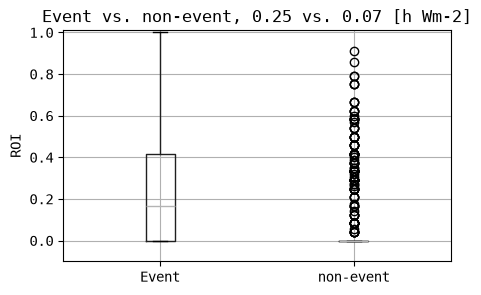

In [58]:
fig = compare_ROI_events_nonevents(df_g_sunflux_cs_D_freq, classification_type='g')
fig = compare_ROI_events_nonevents(df_g_sunflux_cs_D_freq, classification_type='event_norm')

5000000


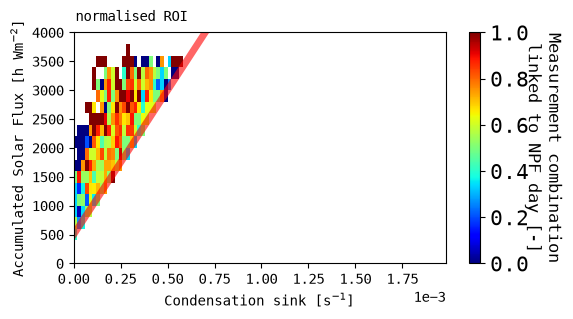

In [59]:
ymax=4000
cs_max=2*10**(-3)
count_threshold=2
count_threshold=None

df_total = df_sunflux_cs_nano.copy()

df_g2g3 = df_sunflux_cs_nano[df_sunflux_cs_nano['g'].isin(['g3', 'g2'])].copy()
df_g2g3events = df_g2g3.copy()

df_g2g3events_ROI = df_g2g3events[df_g2g3events['ROI'] == True].copy()
df_total_ROI = df_total[df_total['ROI'] == True].copy()

total_ROI_count = get_pivot_table(df_total_ROI, NAIS_var='CS', CS_var='CS', 
                    backtraj_var=sun_var_to_use, 
                    ymax=ymax, cs_max=cs_max)
g2g3events_ROI_count = get_pivot_table(df_g2g3events_ROI, NAIS_var='CS', CS_var='CS', 
                   backtraj_var=sun_var_to_use, 
                   ymax=ymax, cs_max=cs_max)

if count_threshold is not None:
    g2g3events_ROI_count = g2g3events_ROI_count[g2g3events_ROI_count>count_threshold]

g2g3events_ROI_norm = g2g3events_ROI_count/total_ROI_count

g2g3events_ROI_count_npnan = g2g3events_ROI_count.replace(0, np.nan)

polormesh_plot(g2g3events_ROI_norm, vmax=1, ymax=4000, x2=0.7*10**(-3), y2=3500, 
               letter_caption='normalised ROI',
               colorbar_label='Measurement combination\nlinked to NPF day [-]',
               cb_labelpad=25, cb_fontsize=12, intercept=500)

In [ ]:
df_sunflux_cs_nano.head(2)

,all_sunflux,CS,mxCS,ROI,g
date,,,,,
2022-04-17,844.885185,0.000329,2147.204277,False,g3
2022-04-17,964.570370,0.000311,2054.025037,False,g3
2022-04-17,1043.777778,0.000271,1855.042379,False,g3
2022-04-17,1073.255556,0.000310,2047.698964,False,g3
2022-04-17,1054.896296,0.000331,2157.319327,False,g3
...,...,...,...,...,...
2024-09-28,76.285185,0.000004,518.764262,False,g1
2024-09-28,50.725926,0.000005,525.651595,False,g1
2024-09-29,30.200000,0.000006,531.473337,False,g1


In [62]:
def select_ROI_to_generate_prob(df_g2g3events, df_total, select_ROI=False):
    df_g2g3events_ROI = df_g2g3events[df_g2g3events['ROI'] == select_ROI].copy()
    df_total_ROI = df_total[df_total['ROI'] == select_ROI].copy()

    total_ROI_count = get_pivot_table(df_total_ROI, NAIS_var='CS', CS_var='CS', 
                        backtraj_var=sun_var_to_use, 
                        ymax=ymax, cs_max=cs_max)
    g2g3events_ROI_count = get_pivot_table(df_g2g3events_ROI, NAIS_var='CS', CS_var='CS', 
                    backtraj_var=sun_var_to_use, 
                    ymax=ymax, cs_max=cs_max)

    if count_threshold is not None:
        g2g3events_ROI_count = g2g3events_ROI_count[g2g3events_ROI_count>count_threshold]

    g2g3events_ROI_norm = g2g3events_ROI_count/total_ROI_count

    polormesh_plot(g2g3events_ROI_norm, vmax=1, ymax=4000, x2=0.7*10**(-3), y2=3500, 
                letter_caption='normalised ROI',
                colorbar_label='Measurement combination\nlinked to NPF day [-]',
                cb_labelpad=25, cb_fontsize=12, intercept=500)
    return g2g3events_ROI_norm

5000000


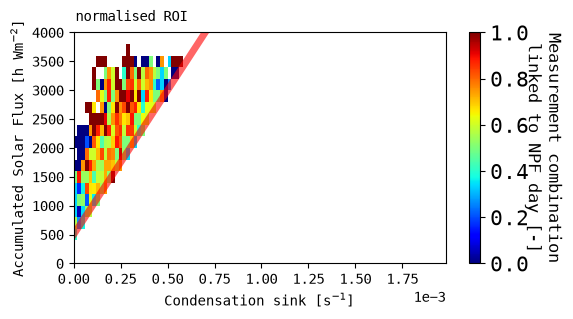

5000000


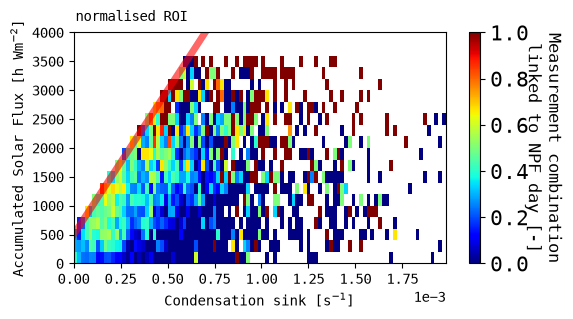

In [63]:
g2g3events_ROI_norm = select_ROI_to_generate_prob(df_g2g3events, df_total, select_ROI=True)
df_prob_ROI = g2g3events_ROI_norm.stack().reset_index().dropna(how='any') 
df_prob_ROI.columns = ['SUN_FLUX_bin_mid','CS_bin_mid', 'prob']

g2g3events_nonROI_norm = select_ROI_to_generate_prob(df_g2g3events, df_total, select_ROI=False)
df_prob_nonROI = g2g3events_nonROI_norm.stack().reset_index().dropna(how='any') 
df_prob_nonROI.columns = ['SUN_FLUX_bin_mid','CS_bin_mid', 'prob']

Mann-Whitney U statistic: 126823.5
P-value: 1.2538864096099807e-22


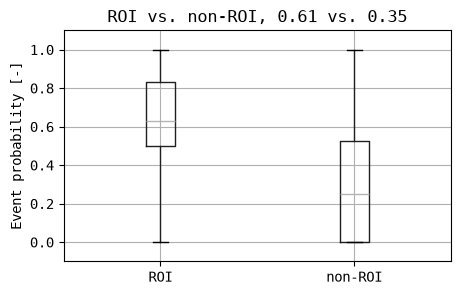

In [67]:
fig, ax = plt.subplots(figsize=(5, 3))

prob_ROI = df_prob_ROI['prob'].values
prob_nonROI = df_prob_nonROI['prob'].values

statistic, p_value = mannwhitneyu(prob_ROI, prob_nonROI, alternative='two-sided')
print(f"Mann-Whitney U statistic: {statistic}")
print(f"P-value: {p_value}")

prob_ROI_median = np.round(np.nanmean(prob_ROI), 2)
prob_nonROI_median = np.round(np.nanmean(prob_nonROI), 2)

boxplot1 = df_prob_ROI.boxplot(column=['prob'], positions=[1], 
                            label=['med = '+str(prob_ROI_median)], ax=ax) 
boxplot2 = df_prob_nonROI.boxplot(column=['prob'], 
                                label=['med = '+str(prob_nonROI_median)], 
                                positions=[2], ax=ax)
ax.set_title('ROI vs. non-ROI, '+str(prob_ROI_median)+' vs. '+str(prob_nonROI_median))
#ax.legend(frameon=False)
ax.set_xticklabels(['ROI', 'non-ROI'])
ax.set_ylabel('Event probability [-]')
ax.set_ylim(-0.1, 1.1)
plt.show()

208
853


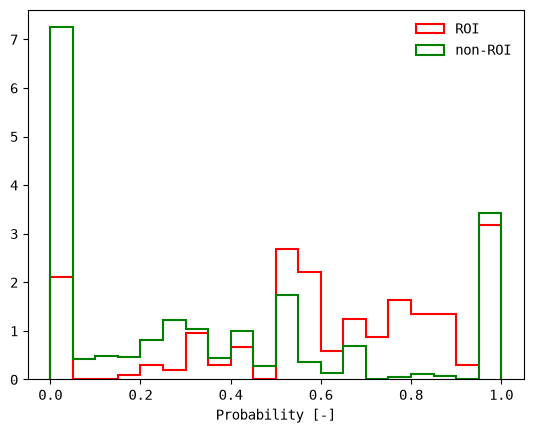

In [68]:
fig, ax = plt.subplots()

prob_ROI = df_prob_ROI['prob'].values
prob_nonROI = df_prob_nonROI['prob'].values

print(len(prob_ROI))
print(len(prob_nonROI))

ax.hist(prob_ROI, 20, ec='red', fc='none', lw=1.5, histtype='step', label='ROI',
        density=True,)
ax.hist(prob_nonROI, 20, ec='green', fc='none', lw=1.5, histtype='step', label='non-ROI',
        density=True,)
#ax.set_yscale('log')
ax.set_xlabel('Probability [-]')
ax.legend(loc='upper right', frameon=False)
plt.show()

One advantage of using the density is therefore that the shape and amplitude of the histogram does not depend on the size of the bins. Consider an extreme case where the bins do not have the same width. In this example, the bins below x=-1.25 are six times wider than the rest of the bins. By normalizing by density, we preserve the shape of the distribution, whereas if we do not, then the wider bins have much higher counts than the thinner bins:

# Dal maso vs. nano-ranking: 

In [69]:
def merge_with_classification(df_sunflux_cs, ZEP_class, df_g_timeseries,
                              merge_with='Nano'):
    df_events = ZEP_class[['Class Ia', 'Class Ib', 'Class II']].sum(axis=1).to_frame(name='event')
    df_sunflux_cs = df_sun_cs_hr.dropna(how='any')
    df_sunflux_cs['date'] = df_sunflux_cs.index.date
    df_sunflux_cs = df_sunflux_cs.set_index('date')

    df_sunflux_cs = df_sunflux_cs[['SUN_FLUX', 'all_sunflux', 'CS']].copy()

    if merge_with == 'Nano':
        df_merged = df_sunflux_cs.merge(df_g_timeseries, left_index=True, right_index=True)
    if merge_with == 'Dalmaso':
        df_merged = df_sunflux_cs.merge(df_events, left_index=True, right_index=True)

    return df_merged

In [70]:
df_dalmaso_sunflux_cs = merge_with_classification(df_sunflux_cs, ZEP_class, df_g_timeseries,
                              merge_with='Dalmaso')

In [71]:
df_event = df_dalmaso_sunflux_cs[df_dalmaso_sunflux_cs['event'] == 1].copy()
df_total = df_dalmaso_sunflux_cs.copy()

In [72]:
def norm_events_by_total(df, ymax=4000, cs_max=2*10**(-3), count_threshold=2,
                        backtraj_var='all_sunflux'):
    
    df_events = df[df['event'] == 1].copy()
    df_total = df.copy()

    total_count = get_pivot_table(df_total, NAIS_var='CS', CS_var='CS', 
                    backtraj_var=backtraj_var, ymax=ymax, cs_max=cs_max)
    event_count = get_pivot_table(df_events, NAIS_var='CS', CS_var='CS', 
                    backtraj_var=backtraj_var, ymax=ymax, cs_max=cs_max)

    total_count = total_count[total_count>count_threshold]
    event_count = event_count[event_count>count_threshold]
    event_norm = event_count/total_count

    polormesh_plot(event_count, vmax=50, ymax=ymax, vmin_log=10**0, vmax_log=10**3, 
                   plot_line=False, use_log_scale=True, letter_caption='event count')
    event_count = event_count.replace(0, np.nan)
    polormesh_plot(event_count, ymax=ymax, vmin=1, vmax=50, plot_line=False, use_log_scale=False,
                   letter_caption='event count (np.nan)')
    polormesh_plot(total_count, vmax=50, ymax=ymax, vmin_log=10**0, vmax_log=10**3, plot_line=False, use_log_scale=True, 
                letter_caption='total', colorbar_label='Count [-]')    
    polormesh_plot(event_norm, vmax=1, ymax=4000, x2=0.7*10**(-3), y2=3500,
                colorbar_label='Measurement combination\nlinked to NPF day [-]',
                cb_labelpad=25, cb_fontsize=12, intercept=500, letter_caption='norm')
    return event_norm

13333333


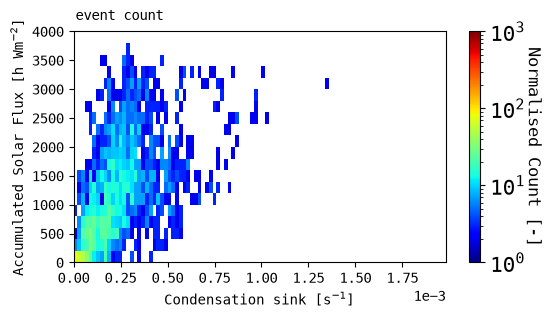

13333333


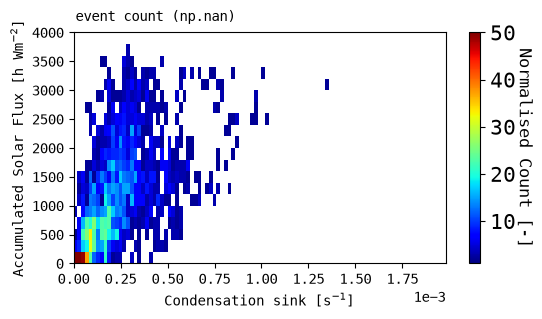

13333333


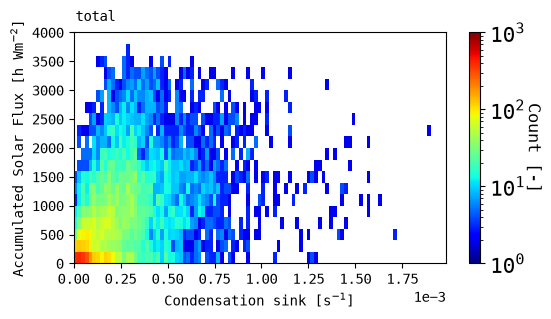

5000000


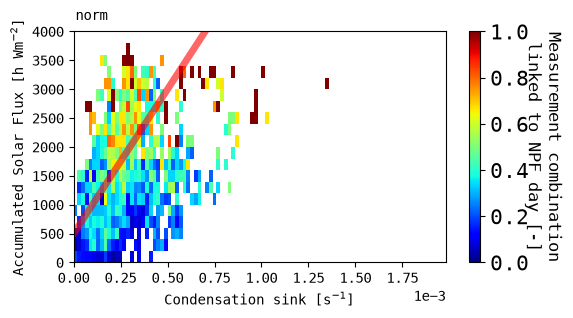

In [73]:
event_norm = norm_events_by_total(df_dalmaso_sunflux_cs, ymax=4000, cs_max=2*10**(-3), 
                     count_threshold=1, backtraj_var='all_sunflux')

In [74]:
def add_ROI_line(df_sun_cs_hr, df_g_timeseries, df_events, 
                 intercept=500, m=5*10**6, sun_var_to_use = 'all_sunflux', 
                 merge_with='Dalmaso'):
    df_sunflux_cs = df_sun_cs_hr[[sun_var_to_use,'CS']].dropna(how='any')
    df_sunflux_cs['date'] = df_sunflux_cs.index.date
    df_sunflux_cs = df_sunflux_cs.set_index('date')
    df_sunflux_cs['mxCS'] = df_sunflux_cs['CS'].apply(lambda x: x*m+intercept) 
    df_sunflux_cs['ROI'] = df_sunflux_cs.apply(lambda row: row[sun_var_to_use]>= row['mxCS'], axis=1)

    if merge_with == 'Nano':
        df_merged = df_sunflux_cs.merge(df_g_timeseries, left_index=True, right_index=True)
        df_merged['g'] = df_merged['g'].replace({'g1':0,'g2':1,'g3':2}) 
    if merge_with == 'Dalmaso':
        df_merged = df_sunflux_cs.merge(df_events, left_index=True, right_index=True)
    return df_merged

In [75]:
df_dalmaso_sunflux_cs_ROI = add_ROI_line(df_sun_cs_hr, df_g_timeseries, df_events, 
                 intercept=500, m=5*10**6, sun_var_to_use = 'all_sunflux', merge_with='Dalmaso')

In [76]:
df_dalmasoevents = df_dalmaso_sunflux_cs_ROI[df_dalmaso_sunflux_cs_ROI['event'] == 1].copy()
df_total = df_dalmaso_sunflux_cs_ROI.copy()

5000000


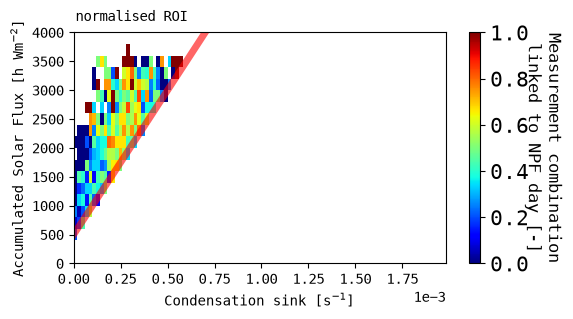

5000000


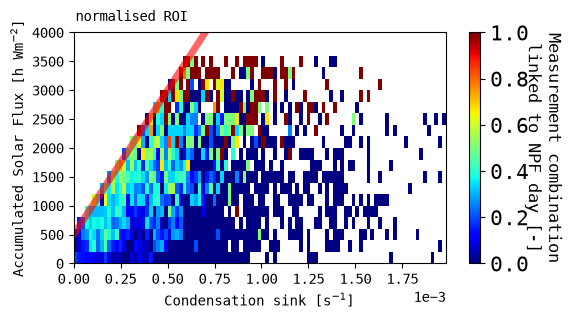

In [77]:
dalmasoevents_ROI_norm = select_ROI_to_generate_prob(df_dalmasoevents, df_total, select_ROI=True)
df_prob_ROI = dalmasoevents_ROI_norm.stack().reset_index().dropna(how='any') 
df_prob_ROI.columns = ['SUN_FLUX_bin_mid','CS_bin_mid', 'prob']

dalmasoevents_nonROI_norm = select_ROI_to_generate_prob(df_dalmasoevents, df_total, select_ROI=False)
df_prob_nonROI = dalmasoevents_nonROI_norm.stack().reset_index().dropna(how='any') 
df_prob_nonROI.columns = ['SUN_FLUX_bin_mid','CS_bin_mid', 'prob']

Mann-Whitney U statistic: 126359.0
P-value: 2.5176222847629557e-24


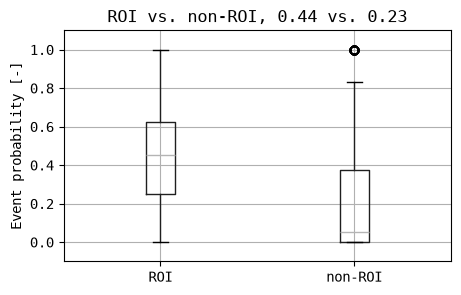

In [80]:
fig, ax = plt.subplots(figsize=(5, 3))

prob_ROI = df_prob_ROI['prob'].values
prob_nonROI = df_prob_nonROI['prob'].values

statistic, p_value = mannwhitneyu(prob_ROI, prob_nonROI, alternative='two-sided')
print(f"Mann-Whitney U statistic: {statistic}")
print(f"P-value: {p_value}")

prob_ROI_median = np.round(np.nanmean(prob_ROI), 2)
prob_nonROI_median = np.round(np.nanmean(prob_nonROI), 2)

boxplot1 = df_prob_ROI.boxplot(column=['prob'], positions=[1], 
                            label=['med = '+str(prob_ROI_median)], ax=ax) 
boxplot2 = df_prob_nonROI.boxplot(column=['prob'], 
                                label=['med = '+str(prob_nonROI_median)], 
                                positions=[2], ax=ax)
ax.set_title('ROI vs. non-ROI, '+str(prob_ROI_median)+' vs. '+str(prob_nonROI_median))
#ax.legend(frameon=False)
ax.set_xticklabels(['ROI', 'non-ROI'])
ax.set_ylabel('Event probability [-]')
ax.set_ylim(-0.1, 1.1)
plt.show()

The p-value from a Mann-Whitney U test indicates the probability of observing the given data (or more extreme) if the null hypothesis—that the two groups come from identical distributions—is true. To interpret it, you compare the p-value to your chosen significance level (alpha, often 0.05). If the p-value is less than alpha, you reject the null hypothesis, concluding there's a statistically significant difference between the groups.

In [81]:
def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('')

def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value

In [ ]:
def violin_plots(df_prob_ROI, df_prob_nonROI):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 3))
    prob_ROI = df_prob_ROI['prob'].values
    prob_nonROI = df_prob_nonROI['prob'].values

    statistic, p_value = mannwhitneyu(prob_ROI, prob_nonROI, alternative='two-sided')
    print(f"Mann-Whitney U statistic: {statistic}")
    print(f"P-value: {p_value}")

    prob_ROI_median = np.round(np.nanmean(prob_ROI), 2)
    prob_nonROI_median = np.round(np.nanmean(prob_nonROI), 2)

    ROI = ax.violinplot(prob_ROI, positions=[1], showmeans=False,
                    showmedians=False, showextrema=False)
    for pc in ROI['bodies']:
        pc.set_facecolor('#D43F3A')
        pc.set_edgecolor('black')
        pc.set_alpha(1)

    quartile1 = np.percentile(prob_ROI, q=25)
    medians = np.percentile(prob_ROI, q=50)
    means = np.mean(prob_ROI)
    quartile3 = np.percentile(prob_ROI, q=75)
    inds = np.arange(1, 1 + 1)
    ax.scatter(inds, medians, marker='o', color='white', s=30, zorder=3)
    ax.scatter(inds, means, marker='x', color='white', s=70, zorder=3)
    ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)

    nonROI = ax.violinplot(prob_nonROI, positions=[2], showmeans=False, showmedians=False,
                showextrema=False)

    for pc in nonROI['bodies']:
        pc.set_facecolor('#3035ba')
        pc.set_edgecolor('black')
        pc.set_alpha(1)

    quartile1 = np.percentile(prob_nonROI, q=25)
    medians = np.percentile(prob_nonROI, q=50)
    means = np.mean(prob_nonROI)
    quartile3 = np.percentile(prob_nonROI, q=75)
    inds = np.arange(2, 3)
    ax.scatter(inds, medians, marker='o', color='white', s=30, zorder=3)
    ax.scatter(inds, means, marker='x', color='white', s=30, zorder=3)
    ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)

    labels = ['ROI', 'non-ROI']
    set_axis_style(ax, labels)

    # p_value = np.round(np.nanmean(p_value), 30)
    if p_value < 0.05:
        p_value_string = 'p<0.05'

    ax.set_title('ROI vs. non-ROI, '+str(prob_ROI_median)+' vs. '+str(prob_nonROI_median)+' '+str(p_value_string))
    #ax.legend(frameon=False)
    ax.set_xticklabels(['ROI', 'non-ROI'])
    ax.set_ylabel('Event probability [-]')
    ax.set_xlabel('')
    ax.set_ylim(-0.1, 1.1)
    plt.show()

Mann-Whitney U statistic: 126359.0
P-value: 2.5176222847629557e-24


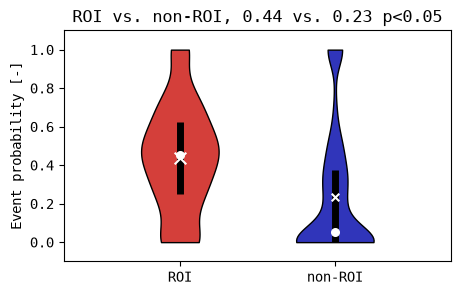

In [83]:
fig = violin_plots(df_prob_ROI, df_prob_nonROI)

In [84]:
df_dalmaso_sunflux_cs_ROI = add_ROI_line(df_sun_cs_hr, df_g_timeseries, df_events, 
                 intercept=500, m=5*10**6, sun_var_to_use = 'all_sunflux', merge_with='Dalmaso')

df_dalmasoevents = df_dalmaso_sunflux_cs_ROI[df_dalmaso_sunflux_cs_ROI['event'] == 1].copy()
df_nondalmasoevents = df_dalmaso_sunflux_cs_ROI[df_dalmaso_sunflux_cs_ROI['event'] == 0].copy()
df_total = df_dalmaso_sunflux_cs_ROI.copy()

In [86]:
df_ROI = df_dalmaso_sunflux_cs_ROI[df_dalmaso_sunflux_cs_ROI['ROI'] == True].copy()
df_nonROI = df_dalmaso_sunflux_cs_ROI[df_dalmaso_sunflux_cs_ROI['ROI'] == False].copy()

In [87]:
def violin_plots(df_var, df_var_non, var='prob', columns=['ROI', 'non-ROI'],
                 ylabel='Event probability [-]', dec_points=2, title='ROI vs. non-ROI'):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 3))
    var_ = df_var[var].values
    var_non = df_var_non[var].values

    print(var_)
    print(var_non)

    statistic, p_value = mannwhitneyu(var_, var_non, alternative='two-sided')
    print(f"Mann-Whitney U statistic: {statistic}")
    print(f"P-value: {p_value}")

    var_mean = np.round(np.nanmean(var_), dec_points)
    var_non_mean = np.round(np.nanmean(var_non), dec_points)

    _violin = ax.violinplot(var_, positions=[1], showmeans=False, showmedians=False, 
                            showextrema=False)
    for pc in _violin['bodies']:
        pc.set_facecolor('#D43F3A')
        pc.set_edgecolor('black')
        pc.set_alpha(1)
    #ROI['cmaxes'].set_color('black')
    #ROI['cmins'].set_color('black')
    #ROI['cbars'].set_color('black')

    quartile1 = np.percentile(var_, q=25)
    medians = np.percentile(var_, q=50)
    means = np.mean(var_)
    quartile3 = np.percentile(var_, q=75)
    inds = np.arange(1, 1 + 1)
    ax.scatter(inds, medians, marker='o', color='white', s=30, zorder=3)
    ax.scatter(inds, means, marker='x', color='white', s=70, zorder=3)
    ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)

    non_violin = ax.violinplot(var_non, positions=[2], showmeans=False, showmedians=False,
                showextrema=False)

    for pc in non_violin['bodies']:
        pc.set_facecolor('#3035ba')
        pc.set_edgecolor('black')
        pc.set_alpha(1)

    #nonROI['cmaxes'].set_color('black')
    #nonROI['cmins'].set_color('black')
    #nonROI['cbars'].set_color('black')

    quartile1 = np.percentile(var_non, q=25)
    non_medians = np.percentile(var_non, q=50)
    means = np.mean(var_non)
    quartile3 = np.percentile(var_non, q=75)
    inds = np.arange(2, 3)
    ax.scatter(inds, non_medians, marker='o', color='white', s=30, zorder=3)
    ax.scatter(inds, means, marker='x', color='white', s=30, zorder=3)
    ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)

    labels = columns
    set_axis_style(ax, labels)

    # p_value = np.round(np.nanmean(p_value), 30)
    if p_value < 0.05:
        p_value_string = 'p<0.05'
    if p_value > 0.05:
        p_value_string = 'p>0.05'

    #ax.set_title(str(title)+', '+str(var_mean)+' vs. '+str(var_non_mean)+' '+str(p_value_string))
    #ax.legend(frameon=False)
    ax.set_xticklabels(columns)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    #ax.set_ylim(-0.1, 1.1)
    plt.show()

[332.54444444 235.54074074 163.19259259 ... 779.72592593 592.06296296
 421.87407407]
[ 844.88518519  964.57037037 1043.77777778 ...   30.2          14.98148148
    4.84814815]
Mann-Whitney U statistic: 32349640.0
P-value: 0.0


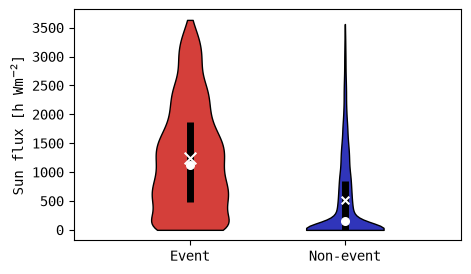

[3.37842762e-04 3.26611612e-04 3.15845469e-04 ... 9.90736091e-05
 1.15967344e-04 9.16490324e-05]
[3.29440855e-04 3.10805007e-04 2.71008476e-04 ... 6.29466738e-06
 7.85248049e-06 7.21208615e-06]
Mann-Whitney U statistic: 24316689.0
P-value: 2.584100990862688e-33


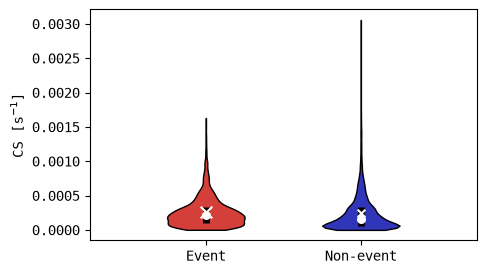

In [88]:
violin_plots(df_dalmasoevents, df_nondalmasoevents, var='all_sunflux', 
             columns=['Event', 'Non-event'],
             ylabel='Sun flux [h Wm$^{-2}$]', title='Event vs. non-event')
violin_plots(df_dalmasoevents, df_nondalmasoevents, var='CS', columns=['Event', 'Non-event'],
             ylabel='CS [s$^{-1}$]', dec_points=5, title='Event vs. non-event')

[1418.47037037 1454.32222222 1624.51481481 ... 1100.25925926  962.32592593
  911.47777778]
[ 844.88518519  964.57037037 1043.77777778 ...   30.2          14.98148148
    4.84814815]


Mann-Whitney U statistic: 23934820.0
P-value: 0.0


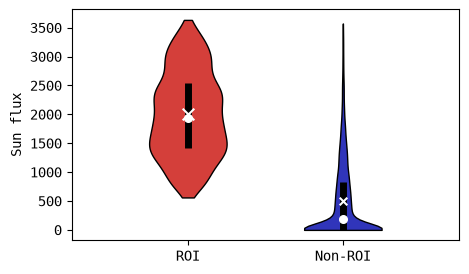

[1.79008284e-04 1.87944120e-04 2.07519103e-04 ... 9.21293613e-05
 8.75077393e-05 7.83683880e-05]
[3.29440855e-04 3.10805007e-04 2.71008476e-04 ... 6.29466738e-06
 7.85248049e-06 7.21208615e-06]
Mann-Whitney U statistic: 12903684.0
P-value: 0.8455079172391666


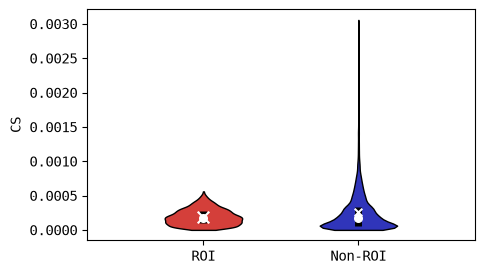

In [89]:
violin_plots(df_ROI, df_nonROI, var='all_sunflux', 
             columns=['ROI', 'Non-ROI'],
             ylabel='Sun flux')
violin_plots(df_ROI, df_nonROI, var='CS', columns=['ROI', 'Non-ROI'],
             ylabel='CS', dec_points=5)

In [90]:
df_dalmaso_sunflux_cs_ROI = add_ROI_line(df_sun_cs_hr, df_g_timeseries, df_events, 
                 intercept=500, m=5*10**6, sun_var_to_use = 'all_sunflux', merge_with='Dalmaso')
df_nano_sunflux_cs_ROI = add_ROI_line(df_sun_cs_hr, df_g_timeseries, df_events, 
                 intercept=500, m=5*10**6, sun_var_to_use = 'all_sunflux', merge_with='Nano')

#dalmaso
df_dalmasoevents = df_dalmaso_sunflux_cs_ROI[df_dalmaso_sunflux_cs_ROI['event'] == 1].copy()
df_nondalmasoevents = df_dalmaso_sunflux_cs_ROI[df_dalmaso_sunflux_cs_ROI['event'] == 0].copy()

#nano
df_nanoevents = df_nano_sunflux_cs_ROI[df_nano_sunflux_cs_ROI['g'] == 1].copy()
df_nonnanoevents = df_nano_sunflux_cs_ROI[df_nano_sunflux_cs_ROI['g'] == 0].copy()

#ROI vs non-ROI 
#Dalmso
df_dalmaso_ROI = df_dalmaso_sunflux_cs_ROI[df_dalmaso_sunflux_cs_ROI['ROI'] == True].copy()
df_dalmaso_nonROI = df_dalmaso_sunflux_cs_ROI[df_dalmaso_sunflux_cs_ROI['ROI'] == False].copy()

df_nano_ROI = df_nano_sunflux_cs_ROI[df_nano_sunflux_cs_ROI['ROI'] == True].copy()
df_nano_nonROI = df_nano_sunflux_cs_ROI[df_nano_sunflux_cs_ROI['ROI'] == False].copy()

In [91]:
### hourly values that go into the grids if ROI is selected the following are true

mean_dalmaso_ROI_selected = df_dalmaso_ROI['event'].mean()
print(mean_dalmaso_ROI_selected)
mean_dalmasoevent_nonROI_selected = df_dalmaso_nonROI['event'].mean()
print(mean_dalmasoevent_nonROI_selected)

mean_nanoevent_ROI_selected = df_nano_ROI['g'].mean()
print(mean_nanoevent_ROI_selected)
mean_nanoevent_nonROI_selected = df_nano_nonROI['g'].mean()
print(mean_nanoevent_nonROI_selected)

0.437066974595843
0.16121260791005823
0.8772036474164133
0.30949956357288333


In [92]:
def alter_violin(_violin, var_, position=1, facecolour='#D43F3A', ax=None):
    for pc in _violin['bodies']:
        pc.set_facecolor(facecolour)
        pc.set_edgecolor('black')
        pc.set_alpha(1)

    quartile1 = np.percentile(var_, q=25)
    medians = np.percentile(var_, q=50)
    means = np.mean(var_)
    quartile3 = np.percentile(var_, q=75)
    inds = np.arange(position, position+1)
    ax.scatter(inds, medians, marker='o', color='white', s=30, zorder=3)
    ax.scatter(inds, means, marker='x', color='white', s=70, zorder=3)
    ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)

In [102]:
def violin_plots(df_var, df_var_non, df2_var, df2_var_non, var='prob', 
                 columns=['DalMaso\nROI', 'non-ROI', 'Nano-ranking\nROI', 'non-ROI'],
                 ylabel='Event probability [-]', dec_points=2, title='ROI vs. non-ROI',
                 y_text=3500, letter='a)'):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 3)) 

    var_ = df_var[var].values
    var_non = df_var_non[var].values

    statistic, p_value = mannwhitneyu(var_, var_non, alternative='two-sided')
    if p_value < 0.05:
        p_value_string = 'p<0.05'
    if p_value > 0.05:
        p_value_string = 'p>0.05'
   
    _violin = ax.violinplot(var_, positions=[1], showmeans=False, showmedians=False, 
                            showextrema=False)
    alter_violin(_violin, var_, position=1, facecolour='#D43F3A', ax=ax)
    _violin = ax.violinplot(var_non, positions=[2], showmeans=False, showmedians=False, 
                            showextrema=False)
    alter_violin(_violin, var_non, position=2, facecolour="#5F1E1C", ax=ax)
    ax.text(0.4, np.percentile(var_, 99)*0.95, p_value_string)

    var_ = df2_var[var].values
    var_non = df2_var_non[var].values   

    statistic, p_value = mannwhitneyu(var_, var_non, alternative='two-sided')
    if p_value < 0.05:
        p_value_string = 'p<0.05'
    if p_value > 0.05:
        p_value_string = 'p>0.05'

    _violin = ax.violinplot(var_, positions=[3], showmeans=False, showmedians=False, 
                            showextrema=False)
    alter_violin(_violin, var_, position=3, facecolour="#3AD4A3", ax=ax)
    _violin = ax.violinplot(var_non, positions=[4], showmeans=False, showmedians=False, 
                            showextrema=False)
    alter_violin(_violin, var_non, position=4,facecolour="#104130", ax=ax)
    ax.text(4.15, np.percentile(var_, 99)*0.95, p_value_string)

    ax.axvline(x=2.5, ls=':')
    ax.text(0.4, y_text, letter)

    labels = columns
    set_axis_style(ax, labels)
    ax.set_xticklabels(columns)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    plt.show()
    return fig

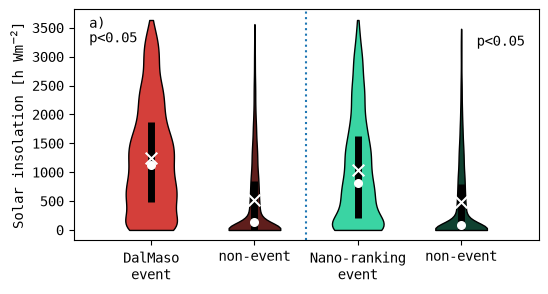

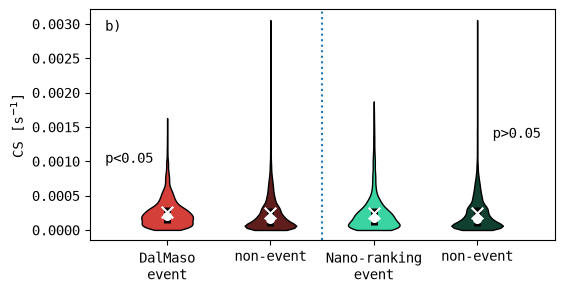

In [94]:
violin_plots(df_dalmasoevents, df_nondalmasoevents, 
             df_nanoevents, df_nonnanoevents, var='all_sunflux',
             columns=['DalMaso\nevent', 'non-event', 'Nano-ranking\nevent', 'non-event'],
             ylabel='Solar insolation [h Wm$^{-2}$]', y_text=3500, letter='a)')
violin_plots(df_dalmasoevents, df_nondalmasoevents, 
             df_nanoevents, df_nonnanoevents, var='CS',
             columns=['DalMaso\nevent', 'non-event', 'Nano-ranking\nevent', 'non-event'],
             ylabel='CS [s$^{-1}$]', y_text=0.0029, letter='b)')

5000000


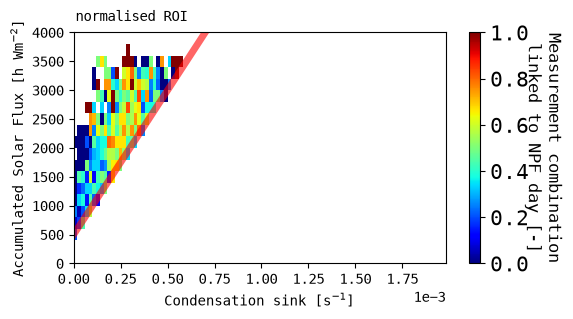

5000000


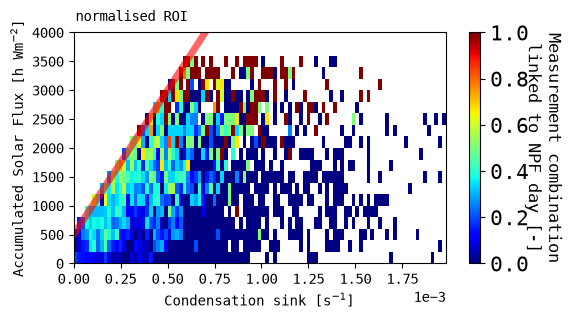

5000000


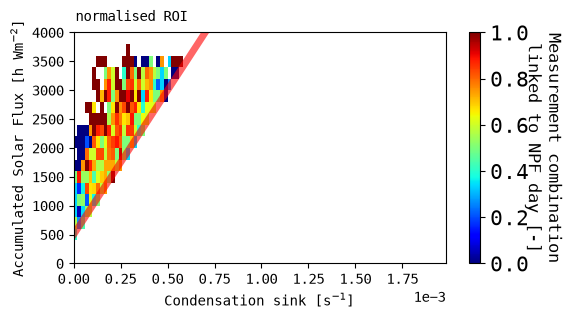

5000000


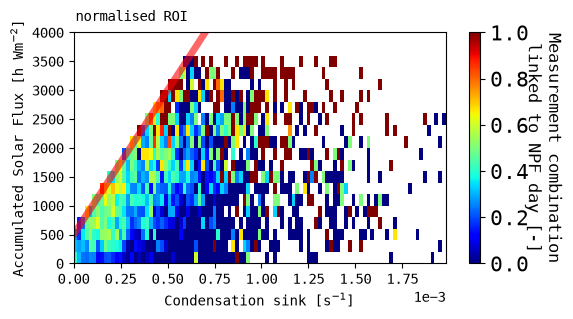

In [95]:
dalmasoevents_ROI_norm = select_ROI_to_generate_prob(df_dalmasoevents, df_total, select_ROI=True)
df_dalmaso_prob_ROI = dalmasoevents_ROI_norm.stack().reset_index().dropna(how='any') 
df_dalmaso_prob_ROI.columns = ['SUN_FLUX_bin_mid','CS_bin_mid', 'prob']

dalmasoevents_nonROI_norm = select_ROI_to_generate_prob(df_dalmasoevents, df_total, select_ROI=False)
df_dalmaso_prob_nonROI = dalmasoevents_nonROI_norm.stack().reset_index().dropna(how='any') 
df_dalmaso_prob_nonROI.columns = ['SUN_FLUX_bin_mid','CS_bin_mid', 'prob']


nanoevents_ROI_norm = select_ROI_to_generate_prob(df_g2g3events, df_total, select_ROI=True)
df_nano_prob_ROI = nanoevents_ROI_norm.stack().reset_index().dropna(how='any') 
df_nano_prob_ROI.columns = ['SUN_FLUX_bin_mid','CS_bin_mid', 'prob']

nano_events_nonROI_norm = select_ROI_to_generate_prob(df_g2g3events, df_total, select_ROI=False)
df_nano_prob_nonROI = g2g3events_nonROI_norm.stack().reset_index().dropna(how='any') 
df_nano_prob_nonROI.columns = ['SUN_FLUX_bin_mid','CS_bin_mid', 'prob']

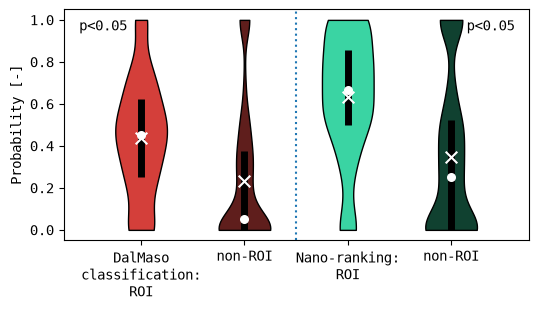

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_9.jpeg


In [104]:
#hourly combinations of measurements within that ROI have a probability that an NPF event will occur that day of 
fig = violin_plots(df_dalmaso_prob_ROI, df_dalmaso_prob_nonROI, 
             df_nano_prob_ROI, df_nano_prob_nonROI, var='prob',
             columns=['DalMaso\nclassification:\nROI', 'non-ROI', 'Nano-ranking:\nROI', 'non-ROI'],
             ylabel='Probability [-]', y_text=1, letter='')

output_figure = plots_outpath / 'Figure_9.jpeg'
save_plot(fig, output_figure)